### Download Data

The data is taken from http://archive.ics.uci.edu/ml/machine-learning-databases/00240/, but you can have it in the form of the UCI-HAR-Dataset.zip.

Extract it to the folder of your notebook with the solution (or suitably adjust the paths to training and test data specified below (TRAIN, TEST).  

Spcifically, the split into training and testing data is already done. The dataset contains 7352 training and 2947 test samples.  

Each sample consists of nine timeseries of float values, each of length 128.

The nine timeseries are collected by an accelerometer and a gyroscope that contain information about the motion and the orientation, respectively.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device is set to: {device}")

Device is set to: cuda


### Load Data

In [3]:
# Useful Constants
TRAIN = "UCI_HAR_Dataset/train/"
TEST = "UCI_HAR_Dataset/test/"

# x-values, 'signals'
# Those are separate normalised input features for the neural network
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]
X_train_signals_paths = [TRAIN + "Inertial Signals/" + signal + "train.txt" for signal in INPUT_SIGNAL_TYPES]
X_test_signals_paths =  [TEST  + "Inertial Signals/" + signal + "test.txt"  for signal in INPUT_SIGNAL_TYPES]


# y-values, 'labels'
#Output classes to learn how to classify
LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]
N_CLASSES = len(LABELS)
y_train_path = TRAIN + "y_train.txt"
y_test_path  = TEST  + "y_test.txt"

In [4]:
# Load "X" (the neural network's training and testing inputs)
def load_X(X_signals_paths):
    X_signals = []
    for signal_type_path in X_signals_paths:
        file = open(signal_type_path, 'r')
        # Read dataset from disk, dealing with text files' syntax
        X_signals.append(
            [np.array(serie, dtype=np.float32) for serie in [
                row.replace('  ', ' ').strip().split(' ') for row in file
            ]]
        )
        file.close()
    return np.transpose(np.array(X_signals), (1, 2, 0))

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)
print(X_train.shape, X_test.shape)

(7352, 128, 9) (2947, 128, 9)


In [5]:
# Load "y" (the neural network's training and testing outputs)
def load_y(y_path):
    file = open(y_path, 'r')
    # Read dataset from disk, dealing with text file's syntax
    y_ = np.array(
        [elem for elem in [
            row.replace('  ', ' ').strip().split(' ') for row in file
        ]],
        dtype=np.int32
    )
    file.close()
    # Substract 1 to each output class for friendly 0-based indexing
    return y_ - 1

def one_hot(y, n_classes):
    y = y.reshape(len(y))
    return np.eye(n_classes)[np.array(y, dtype=np.int32)]

def label_from_onehot(vectors):
    indices = []
    for vector in vectors:
        indices.append(np.argmax(vector))
    return np.array(indices)

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)
print(y_train.shape, y_test.shape)

(7352, 1) (2947, 1)


#### Plot some samples

In [6]:
X_train_per_class = {}
for c in range(N_CLASSES):
    mask = ... # select sample of given class c
    X_train_per_class[c] = X_train[mask]

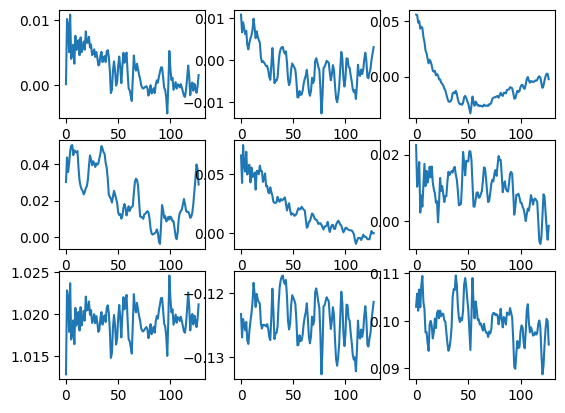

In [7]:
def plot_lines(X, nsamples):
    t = range(128)
    for i in range(9):
        plt.subplot(3,3,i+1)
        for j in range(np.minimum(X.shape[0],nsamples)):
            plt.plot(t,X[j,:,i])
    plt.show()
    
plot_lines(X_train_per_class[1], 1)

In [8]:
# Input Data
training_data_count = len(X_train)  # 7352 training series (with 50% overlap between each serie)
test_data_count = len(X_test)  # 2947 testing series
means = np.mean(X_train, axis=(0,1))
stdevs = np.std(X_train, axis=(0,1))

print("X shape, Y_shape:")
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print()
print("Mean / Stdev for each feature:")
for i in range(9):
    print("%7.4f | %7.4f"%(means[i], stdevs[i]))

X shape, Y_shape:
(7352, 128, 9) (7352, 1)
(2947, 128, 9) (2947, 1)

Mean / Stdev for each feature:
-0.0006 |  0.1948
-0.0003 |  0.1224
-0.0003 |  0.1069
 0.0005 |  0.4068
-0.0008 |  0.3819
 0.0001 |  0.2557
 0.8047 |  0.4141
 0.0288 |  0.3910
 0.0865 |  0.3578


### Dataset

If suitable specify Dataset (e.g. in PyTorch).

In [9]:
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

### Normalization

Normalization was already done on that dataset as mentioned in the README and earlier in that notebook

## Specify and Train Models

Try different architectures to solve the activity recognition problem.

At minimum implement
* Model with a single layer of SimpleRNN
* Model with a single layer of LSTM
* Model with several layers of LSTMs
* Model with several CNN layers
* MLP

Try with different number of units. Add regularisation if needed (e.g. when working with MLPs).

Report about your findings.

In [10]:
def run_epoch(model, dataloader, optimizer, criterion, train=True):
    """
    Runs one epoch for training or validation.
    """
    epoch_loss = 0
    correct = 0
    total_samples = len(dataloader.dataset)
    total_preds = []
    total_targets = []

    if train:
        model.train()
    else:
        model.eval()

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            output = model(X)
            loss = criterion(output, y.long().squeeze())

        epoch_loss += loss.item()
        _, y_pred = torch.max(output, dim=1)
        correct += torch.sum(y_pred == torch.argmax(y, dim=1)).item()

        if train:
            loss.backward()
            optimizer.step()
        else:
            total_preds.append(y_pred.detach().cpu())
            total_targets.append(y.detach().cpu())

    avg_loss = epoch_loss / len(dataloader)
    accuracy = correct / total_samples

    return avg_loss, accuracy, total_preds, total_targets

def trainer(model, train_loader, val_loader, optimizer, criterion, n_epochs, verbose=True):
    """
    Trains and evaluates the model for n_epochs.
    """
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_train_accs = []
    epoch_val_accs = []
    total_preds, total_targets = None, None

    for epoch in range(n_epochs):

        if verbose:
            print(f'\nEpoch {epoch+1}/{n_epochs}')
            print('----------')

        train_loss, train_acc, _, _ = run_epoch(model, train_loader, optimizer, criterion, train=True)
        val_loss, val_acc, total_preds, total_targets = run_epoch(model, val_loader, optimizer, criterion, train=False)

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_train_accs.append(train_acc)
        epoch_val_accs.append(val_acc)

        if verbose or epoch % 10 == 0:
            print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}\nVal Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}')

    return epoch_train_losses, epoch_val_losses, epoch_train_accs, epoch_val_accs, total_preds, total_targets

### Single Layer SimpleRNN

In [11]:
### START YOUR CODE
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True, num_layers=1)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, hidden = self.rnn(x)
        out = self.fc(hidden[-1])
        return out
### END YOUR CODE

Run 1 with hidden_size 128.
Train Loss: 1.4033, Train Accuracy: 0.2228
Val Loss: 1.3762, Val Accuracy: 0.0003
Train Loss: 1.7145, Train Accuracy: 0.1181
Val Loss: 1.5963, Val Accuracy: 0.0000
Train Loss: 1.1557, Train Accuracy: 0.0592
Val Loss: 1.1893, Val Accuracy: 0.0000
Run 2 with hidden_size 256.
Train Loss: 1.4816, Train Accuracy: 0.1461
Val Loss: 1.4349, Val Accuracy: 0.0000
Train Loss: 1.3988, Train Accuracy: 0.1542
Val Loss: 1.4380, Val Accuracy: 0.0068
Train Loss: 1.3765, Train Accuracy: 0.0896
Val Loss: 1.4713, Val Accuracy: 0.0000
Run 3 with hidden_size 512.
Train Loss: 1.4112, Train Accuracy: 0.1239
Val Loss: 1.3464, Val Accuracy: 0.0034
Train Loss: 1.3089, Train Accuracy: 0.2674
Val Loss: 1.3572, Val Accuracy: 0.0000
Train Loss: 1.1694, Train Accuracy: 0.0978
Val Loss: 1.2229, Val Accuracy: 0.0071


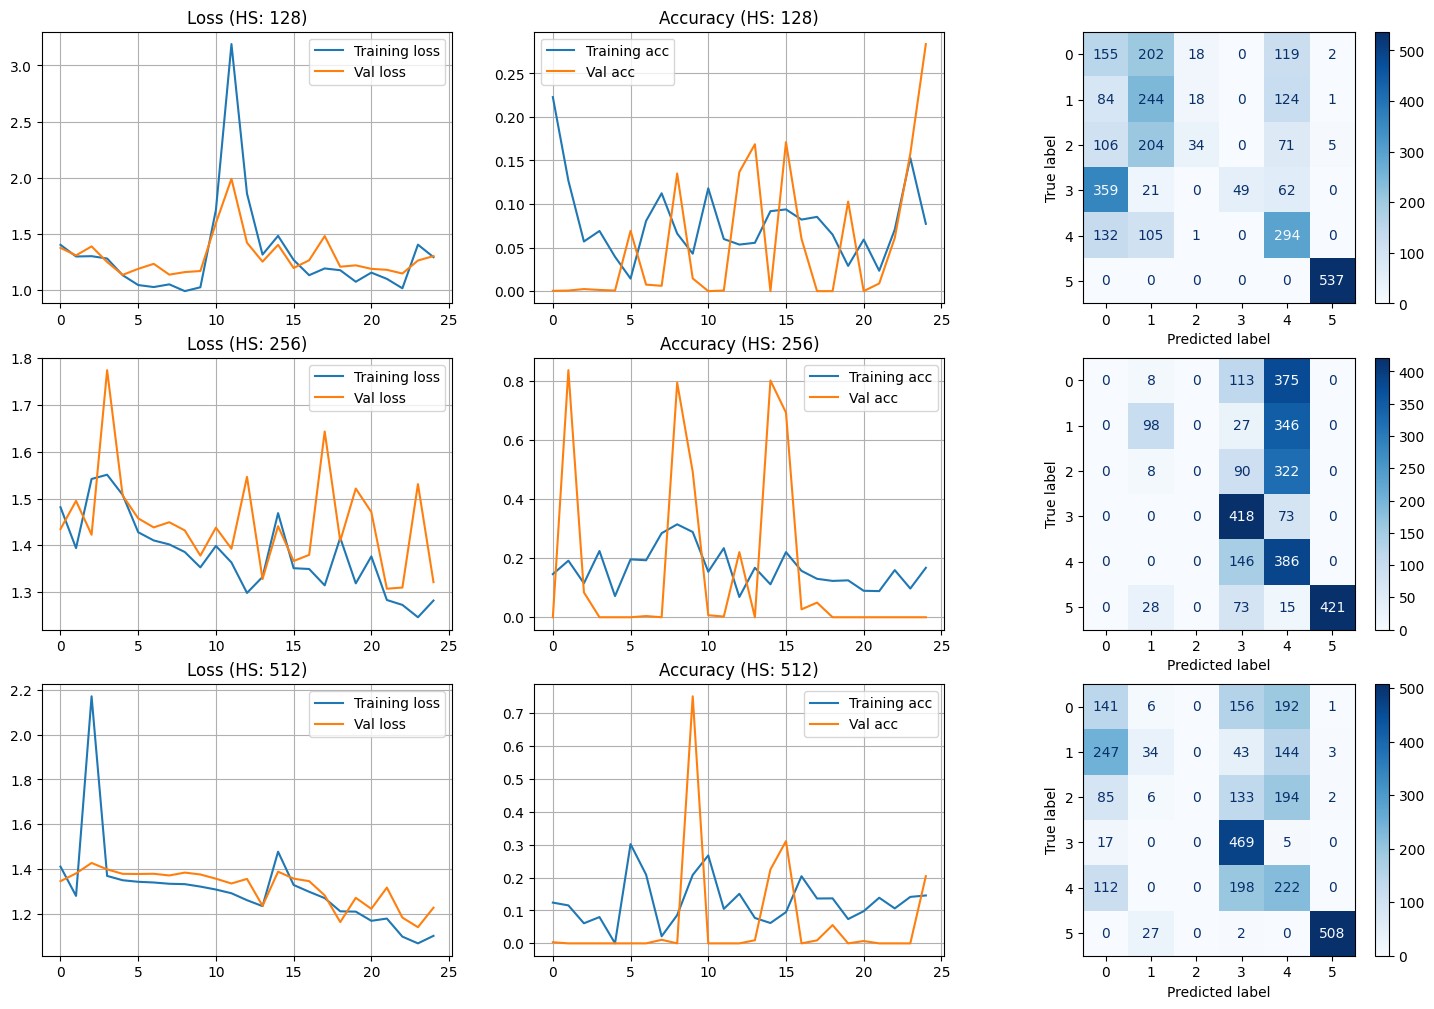

In [12]:
### START YOUR CODE
num_epochs = 25
input_size = X_train.shape[-1]

settings = [
    {
        'hidden_size': 128
    },
    {
        'hidden_size': 256
    },
    {
        'hidden_size': 512
    }
]
criterion = nn.CrossEntropyLoss()

fig, axes = plt.subplots(len(settings), 3, figsize=(18, 4 * len(settings)))


for i, setting in enumerate(settings):
    hidden_size = setting['hidden_size']
    print(f"Run {i+1} with hidden_size {hidden_size}.")

    # Create Model
    model = RNNClassifier(input_size, 512, N_CLASSES).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses, train_accs, val_accs, total_preds, total_targets = trainer(model, train_loader, test_loader, optimizer, criterion, num_epochs, verbose=False)

    axes[i, 0].plot(train_losses, label='Training loss')
    axes[i, 0].plot(val_losses, label='Val loss')
    axes[i, 0].set_title(f"Loss (HS: {hidden_size})")
    axes[i, 0].legend()
    axes[i, 0].grid()

    axes[i, 1].plot(train_accs, label='Training acc')
    axes[i, 1].plot(val_accs, label='Val acc')
    axes[i, 1].set_title(f"Accuracy (HS: {hidden_size})")
    axes[i, 1].legend()
    axes[i, 1].grid()

    cm = confusion_matrix(torch.cat(total_targets), torch.cat(total_preds))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i, 2], cmap="Blues")

plt.show()

#### Findings
The RNN is not really learning any meaningful pattern, predicting just two or three classes out of the total 6. And it is not improving across the epochs, so maybe a single layer RNN is not enough for this kind of problem.


### LSTM

In [13]:
### START YOUR CODE
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True, num_layers=num_layers)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)
        out = self.fc(hidden[-1])
        return out
### END YOUR CODE

Run 1 with hidden_size 128.
Train Loss: 1.5845, Train Accuracy: 0.3279
Val Loss: 1.4142, Val Accuracy: 0.2352
Train Loss: 1.0757, Train Accuracy: 0.3037
Val Loss: 0.9919, Val Accuracy: 0.3892
Train Loss: 1.1876, Train Accuracy: 0.1285
Val Loss: 1.3934, Val Accuracy: 0.2891
Run 2 with hidden_size 256.
Train Loss: 1.4621, Train Accuracy: 0.0004
Val Loss: 1.3843, Val Accuracy: 0.0000
Train Loss: 1.2363, Train Accuracy: 0.0011
Val Loss: 1.3150, Val Accuracy: 0.0003
Train Loss: 1.1867, Train Accuracy: 0.0547
Val Loss: 1.2402, Val Accuracy: 0.0000
Run 3 with hidden_size 512.
Train Loss: 1.4579, Train Accuracy: 0.0000
Val Loss: 1.3907, Val Accuracy: 0.0000
Train Loss: 1.3498, Train Accuracy: 0.1404
Val Loss: 1.3061, Val Accuracy: 0.0014
Train Loss: 0.9924, Train Accuracy: 0.1952
Val Loss: 1.0342, Val Accuracy: 0.3091


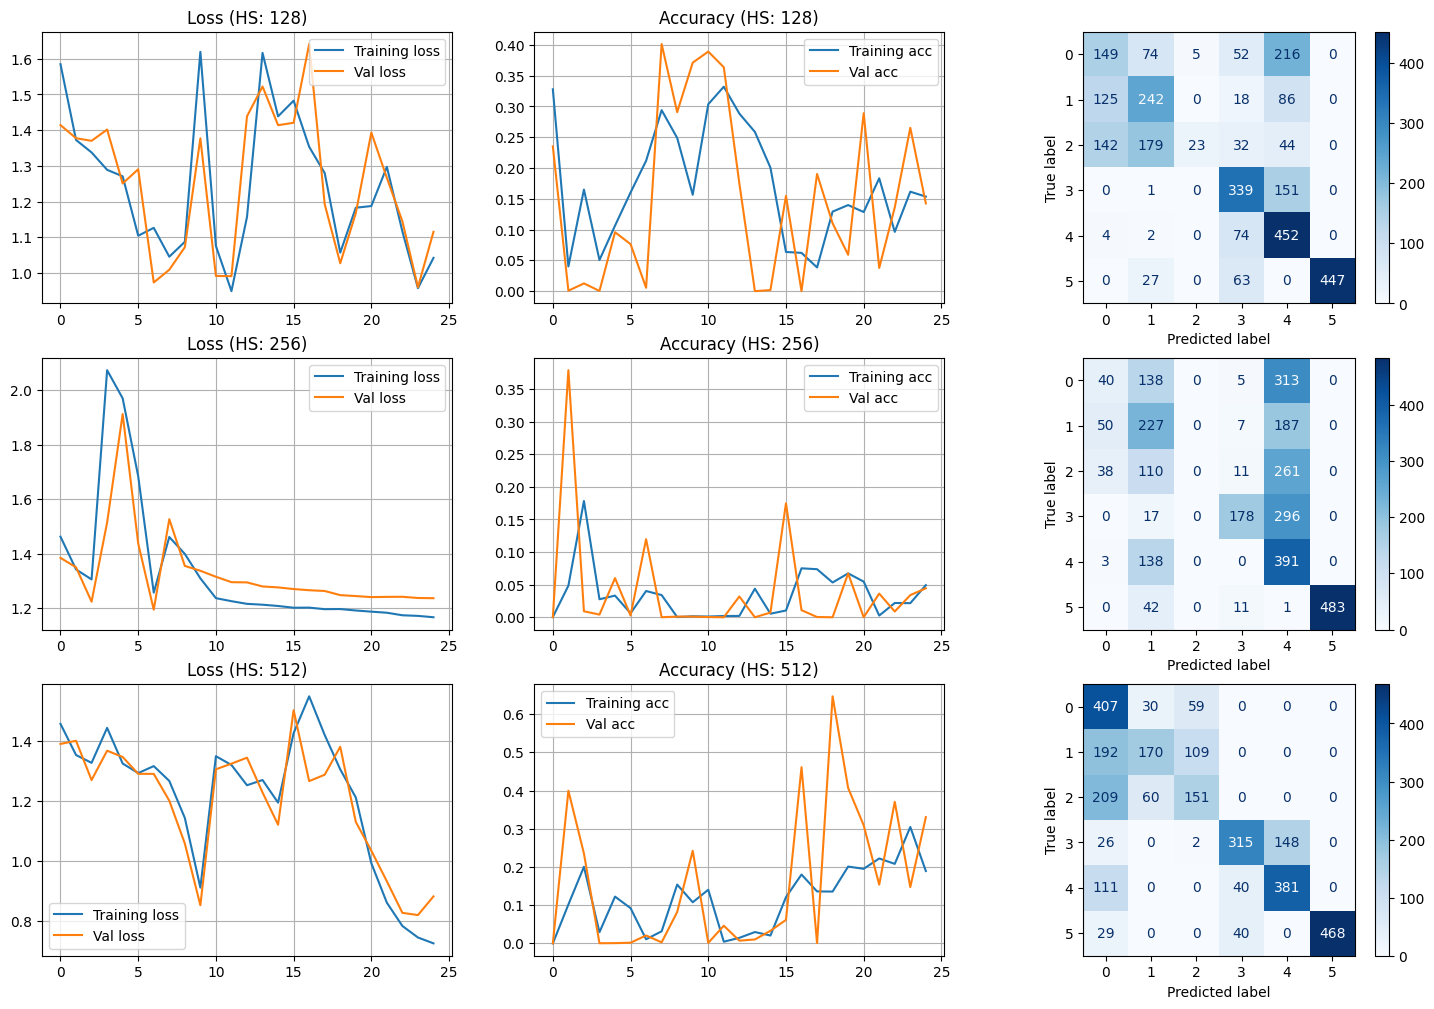

In [14]:
### START YOUR CODE
### START YOUR CODE
num_epochs = 25
input_size = X_train.shape[-1]

settings = [
    {
        'hidden_size': 128
    },
    {
        'hidden_size': 256
    },
    {
        'hidden_size': 512
    }
]
criterion = nn.CrossEntropyLoss()

fig, axes = plt.subplots(len(settings), 3, figsize=(18, 4 * len(settings)))


for i, setting in enumerate(settings):
    hidden_size = setting['hidden_size']
    print(f"Run {i+1} with hidden_size {hidden_size}.")

    # Create Model
    model = LSTMClassifier(input_size, 512, N_CLASSES).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses, train_accs, val_accs, total_preds, total_targets = trainer(model, train_loader, test_loader, optimizer, criterion, num_epochs, verbose=False)

    axes[i, 0].plot(train_losses, label='Training loss')
    axes[i, 0].plot(val_losses, label='Val loss')
    axes[i, 0].set_title(f"Loss (HS: {hidden_size})")
    axes[i, 0].legend()
    axes[i, 0].grid()

    axes[i, 1].plot(train_accs, label='Training acc')
    axes[i, 1].plot(val_accs, label='Val acc')
    axes[i, 1].set_title(f"Accuracy (HS: {hidden_size})")
    axes[i, 1].legend()
    axes[i, 1].grid()

    cm = confusion_matrix(torch.cat(total_targets), torch.cat(total_preds))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i, 2], cmap="Blues")

plt.show()

#### Findings

The LSTM performs much better than the RNN with a larger hidden size. However, the model does still have some difficulities with the classes 0-2 and 3/4, lets see if more layers below can solve that problem.

### Stacked LSTMs

Run 1 with hidden_size 128 and 2 Layers.
Train Loss: 1.6188, Train Accuracy: 0.1196
Val Loss: 1.3756, Val Accuracy: 0.0000
Train Loss: 1.2427, Train Accuracy: 0.0660
Val Loss: 1.2401, Val Accuracy: 0.0974
Train Loss: 0.6311, Train Accuracy: 0.2081
Val Loss: 0.7320, Val Accuracy: 0.1642
Run 2 with hidden_size 256 and 2 Layers.
Train Loss: 1.5140, Train Accuracy: 0.0360
Val Loss: 1.3971, Val Accuracy: 0.0000
Train Loss: 1.4031, Train Accuracy: 0.0034
Val Loss: 1.3519, Val Accuracy: 0.0112
Train Loss: 1.3181, Train Accuracy: 0.0150
Val Loss: 1.3008, Val Accuracy: 0.0000
Run 3 with hidden_size 512 and 2 Layers.
Train Loss: 1.4493, Train Accuracy: 0.0987
Val Loss: 1.3636, Val Accuracy: 0.0000
Train Loss: 1.5092, Train Accuracy: 0.0774
Val Loss: 1.4761, Val Accuracy: 0.2708
Train Loss: 1.3844, Train Accuracy: 0.2013
Val Loss: 1.3778, Val Accuracy: 0.0000
Run 4 with hidden_size 128 and 4 Layers.
Train Loss: 1.6392, Train Accuracy: 0.0001
Val Loss: 2.1009, Val Accuracy: 0.0000
Train Loss: 1.29

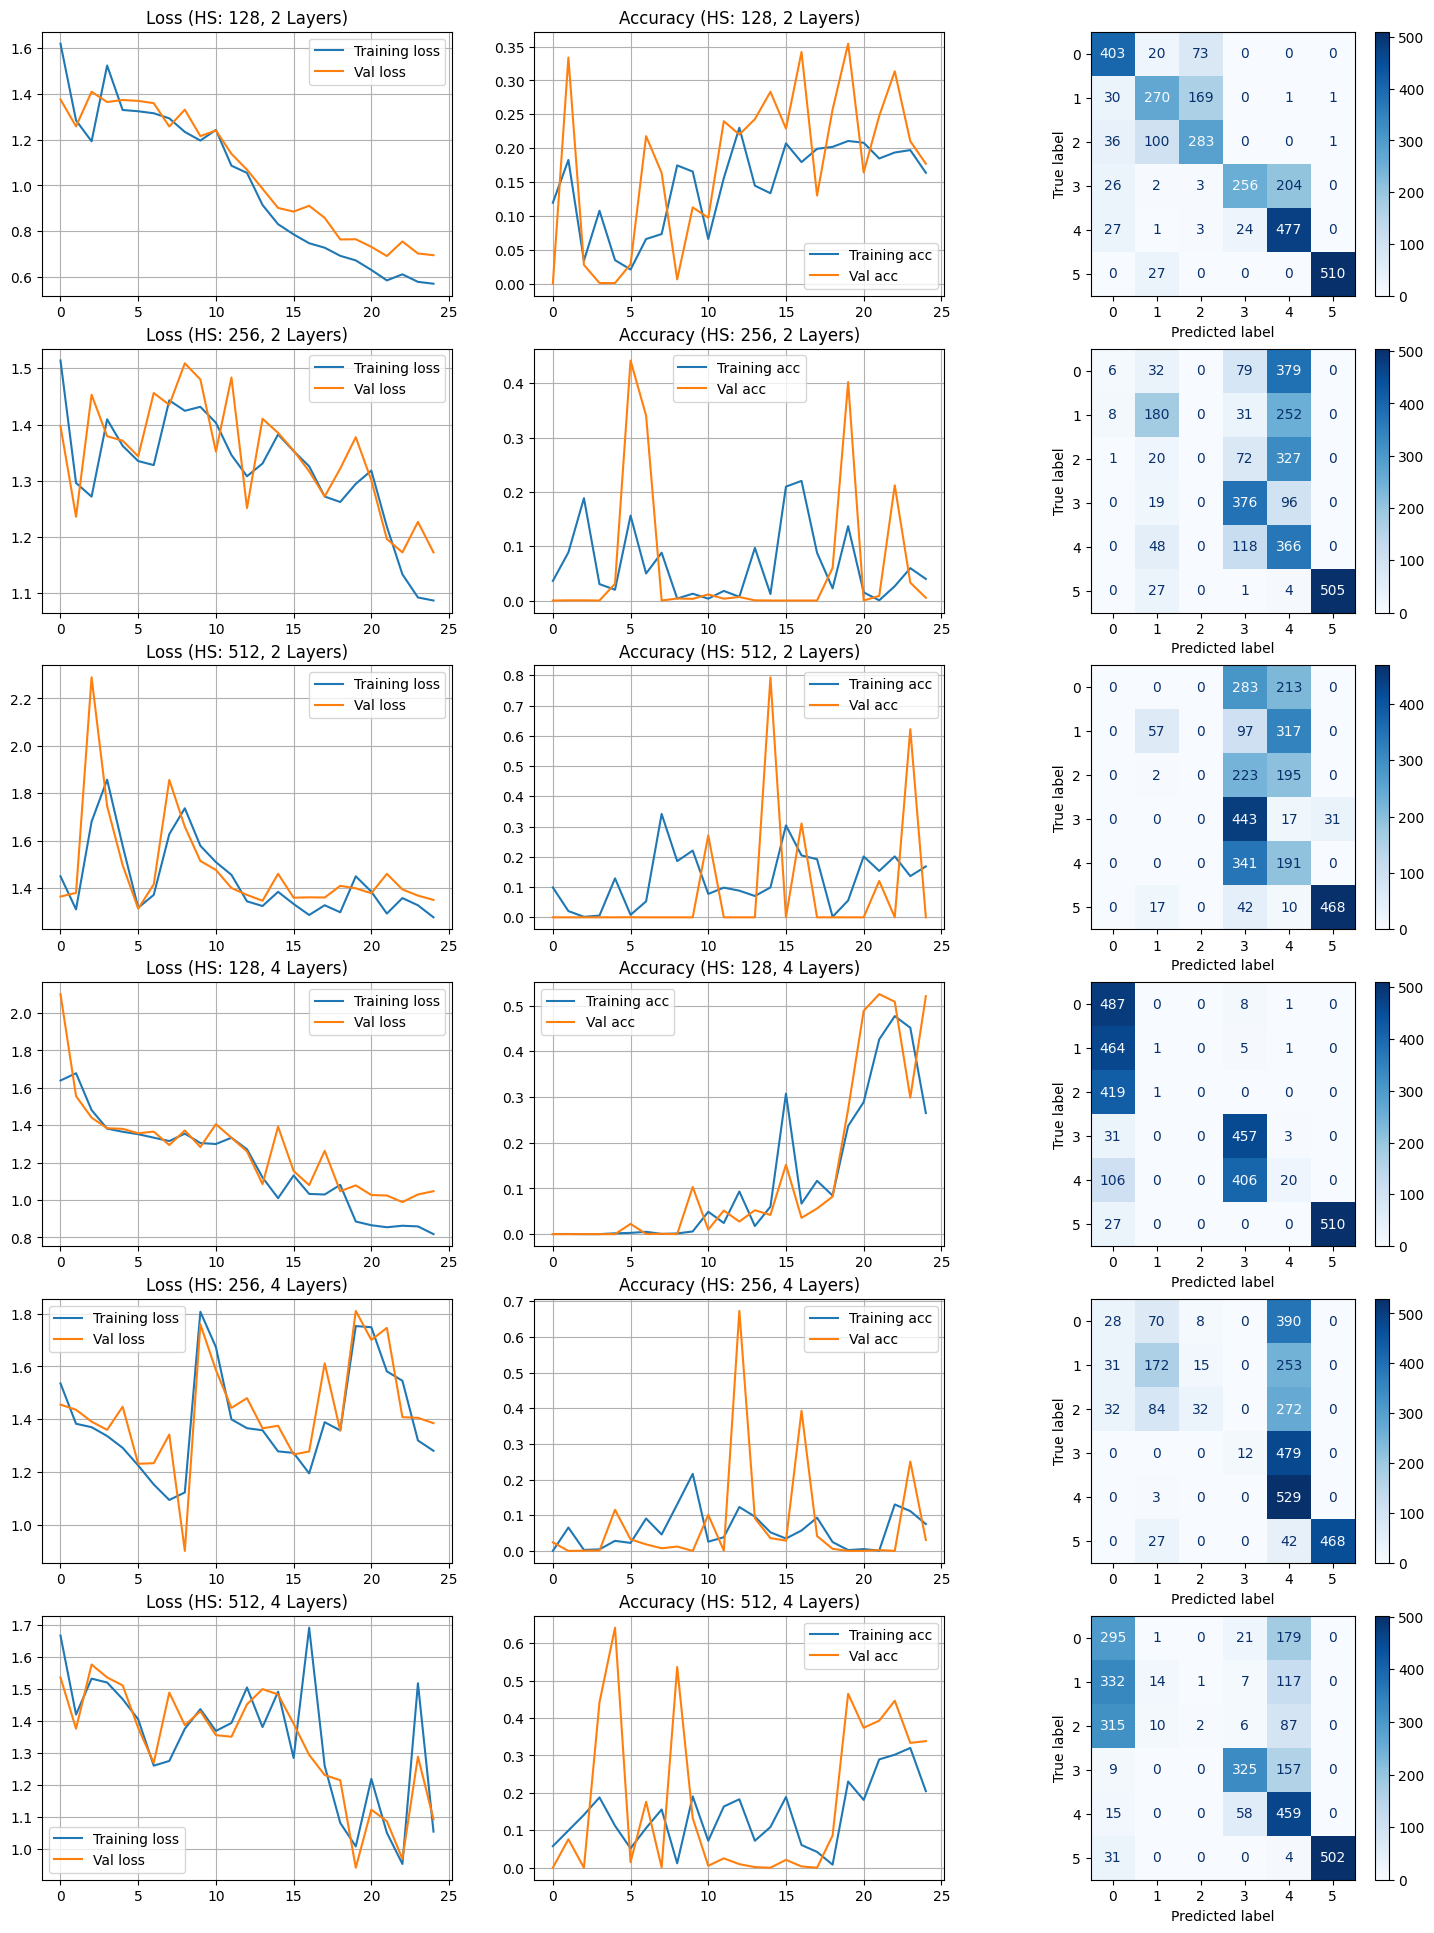

In [15]:
### START YOUR CODE
num_epochs = 25
input_size = X_train.shape[-1]

settings = [
    {
        'num_layers': 2,
        'hidden_size': 128
    },
    {
        'num_layers': 2,
        'hidden_size': 256
    },
    {
        'num_layers': 2,
        'hidden_size': 512
    },
    {
        'num_layers': 4,
        'hidden_size': 128
    },
    {
        'num_layers': 4,
        'hidden_size': 256
    },
    {
        'num_layers': 4,
        'hidden_size': 512
    }
]
criterion = nn.CrossEntropyLoss()

fig, axes = plt.subplots(len(settings), 3, figsize=(18, 4 * len(settings)))


for i, setting in enumerate(settings):
    hidden_size = setting['hidden_size']
    num_layers = setting['num_layers']
    print(f"Run {i+1} with hidden_size {hidden_size} and {num_layers} Layers.")

    # Create Model
    model = LSTMClassifier(input_size, hidden_size, N_CLASSES).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses, train_accs, val_accs, total_preds, total_targets = trainer(model, train_loader, test_loader, optimizer, criterion, num_epochs, verbose=False)

    axes[i, 0].plot(train_losses, label='Training loss')
    axes[i, 0].plot(val_losses, label='Val loss')
    axes[i, 0].set_title(f"Loss (HS: {hidden_size}, {num_layers} Layers)")
    axes[i, 0].legend()
    axes[i, 0].grid()

    axes[i, 1].plot(train_accs, label='Training acc')
    axes[i, 1].plot(val_accs, label='Val acc')
    axes[i, 1].set_title(f"Accuracy (HS: {hidden_size}, {num_layers} Layers)")
    axes[i, 1].legend()
    axes[i, 1].grid()

    cm = confusion_matrix(torch.cat(total_targets), torch.cat(total_preds))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i, 2], cmap="Blues")

plt.show()

#### Findings

A bit of a strange behaviour here. 4 Layers did no get better results as some classes get predicted too often. With 2 Layers we see that a smaller hidden size like 128 yields the best result. Any higher than that reduces the performance. But we do still have problems within class 1/2 and 3/4.

### CNN (Conv1d)

In [16]:
### START YOUR CODE
class CNNClassifier(nn.Module):
    def __init__(self, output_size):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=(3, 3), padding="same")
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding="same")
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.dropout = nn.Dropout(0.3)

        self.flatten = nn.Flatten()
        # After a pooling layers, the shape will be reduced
        # From (128, 9) → (64, 4)
        self.flatten_dim = 32 * 64 * 4
        self.fc = nn.Linear(self.flatten_dim, output_size)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = self.flatten(x)
        out = self.fc(x)
        return out
### END YOUR CODE

Train Loss: 0.8623, Train Accuracy: 0.2108
Val Loss: 0.5914, Val Accuracy: 0.2053
Train Loss: 0.1636, Train Accuracy: 0.1662
Val Loss: 0.4046, Val Accuracy: 0.1649
Train Loss: 0.1191, Train Accuracy: 0.1666
Val Loss: 0.4414, Val Accuracy: 0.1371


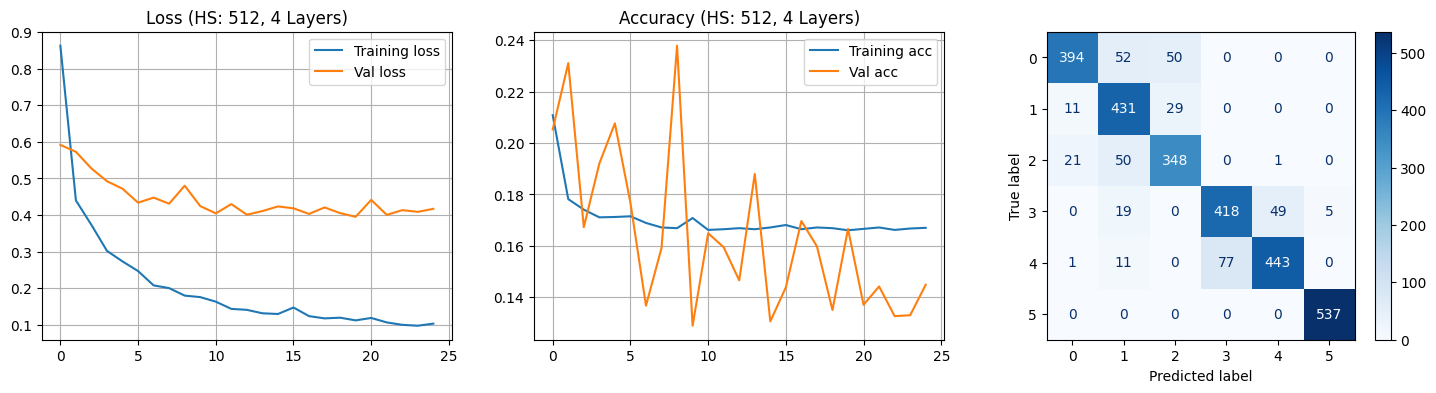

In [17]:
### START YOUR CODE
num_epochs = 25

criterion = nn.CrossEntropyLoss()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Create Model
model = CNNClassifier(N_CLASSES).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses, train_accs, val_accs, total_preds, total_targets = trainer(model, train_loader, test_loader, optimizer, criterion, num_epochs, verbose=False)

axes[0].plot(train_losses, label='Training loss')
axes[0].plot(val_losses, label='Val loss')
axes[0].set_title(f"Loss CNN")
axes[0].legend()
axes[0].grid()

axes[1].plot(train_accs, label='Training acc')
axes[1].plot(val_accs, label='Val acc')
axes[1].set_title(f"Accuracy CNN")
axes[1].legend()
axes[1].grid()

cm = confusion_matrix(torch.cat(total_targets), torch.cat(total_preds))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[2], cmap="Blues")

plt.show()

#### Findings

A CNN seems to be the best performing models, as it can distinguish between the classes the best. It still does have some problems between class 0-2 and 3/4, but way smaller compared to the previous RNN/LSTM Models.

### MLP

In [19]:
class MLPClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.layers = [nn.Flatten(), nn.Linear(input_size, hidden_size), nn.ReLU()]

        for _ in range(num_layers - 1):
            self.layers.append(nn.Linear(hidden_size, hidden_size))
            self.layers.append(nn.ReLU())

        self.layers.append(nn.Linear(hidden_size, output_size))
        self.layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*self.layers)

    def forward(self, x):
        return self.network(x)

Run 1 with hidden_size 512 and 2 Layers.


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


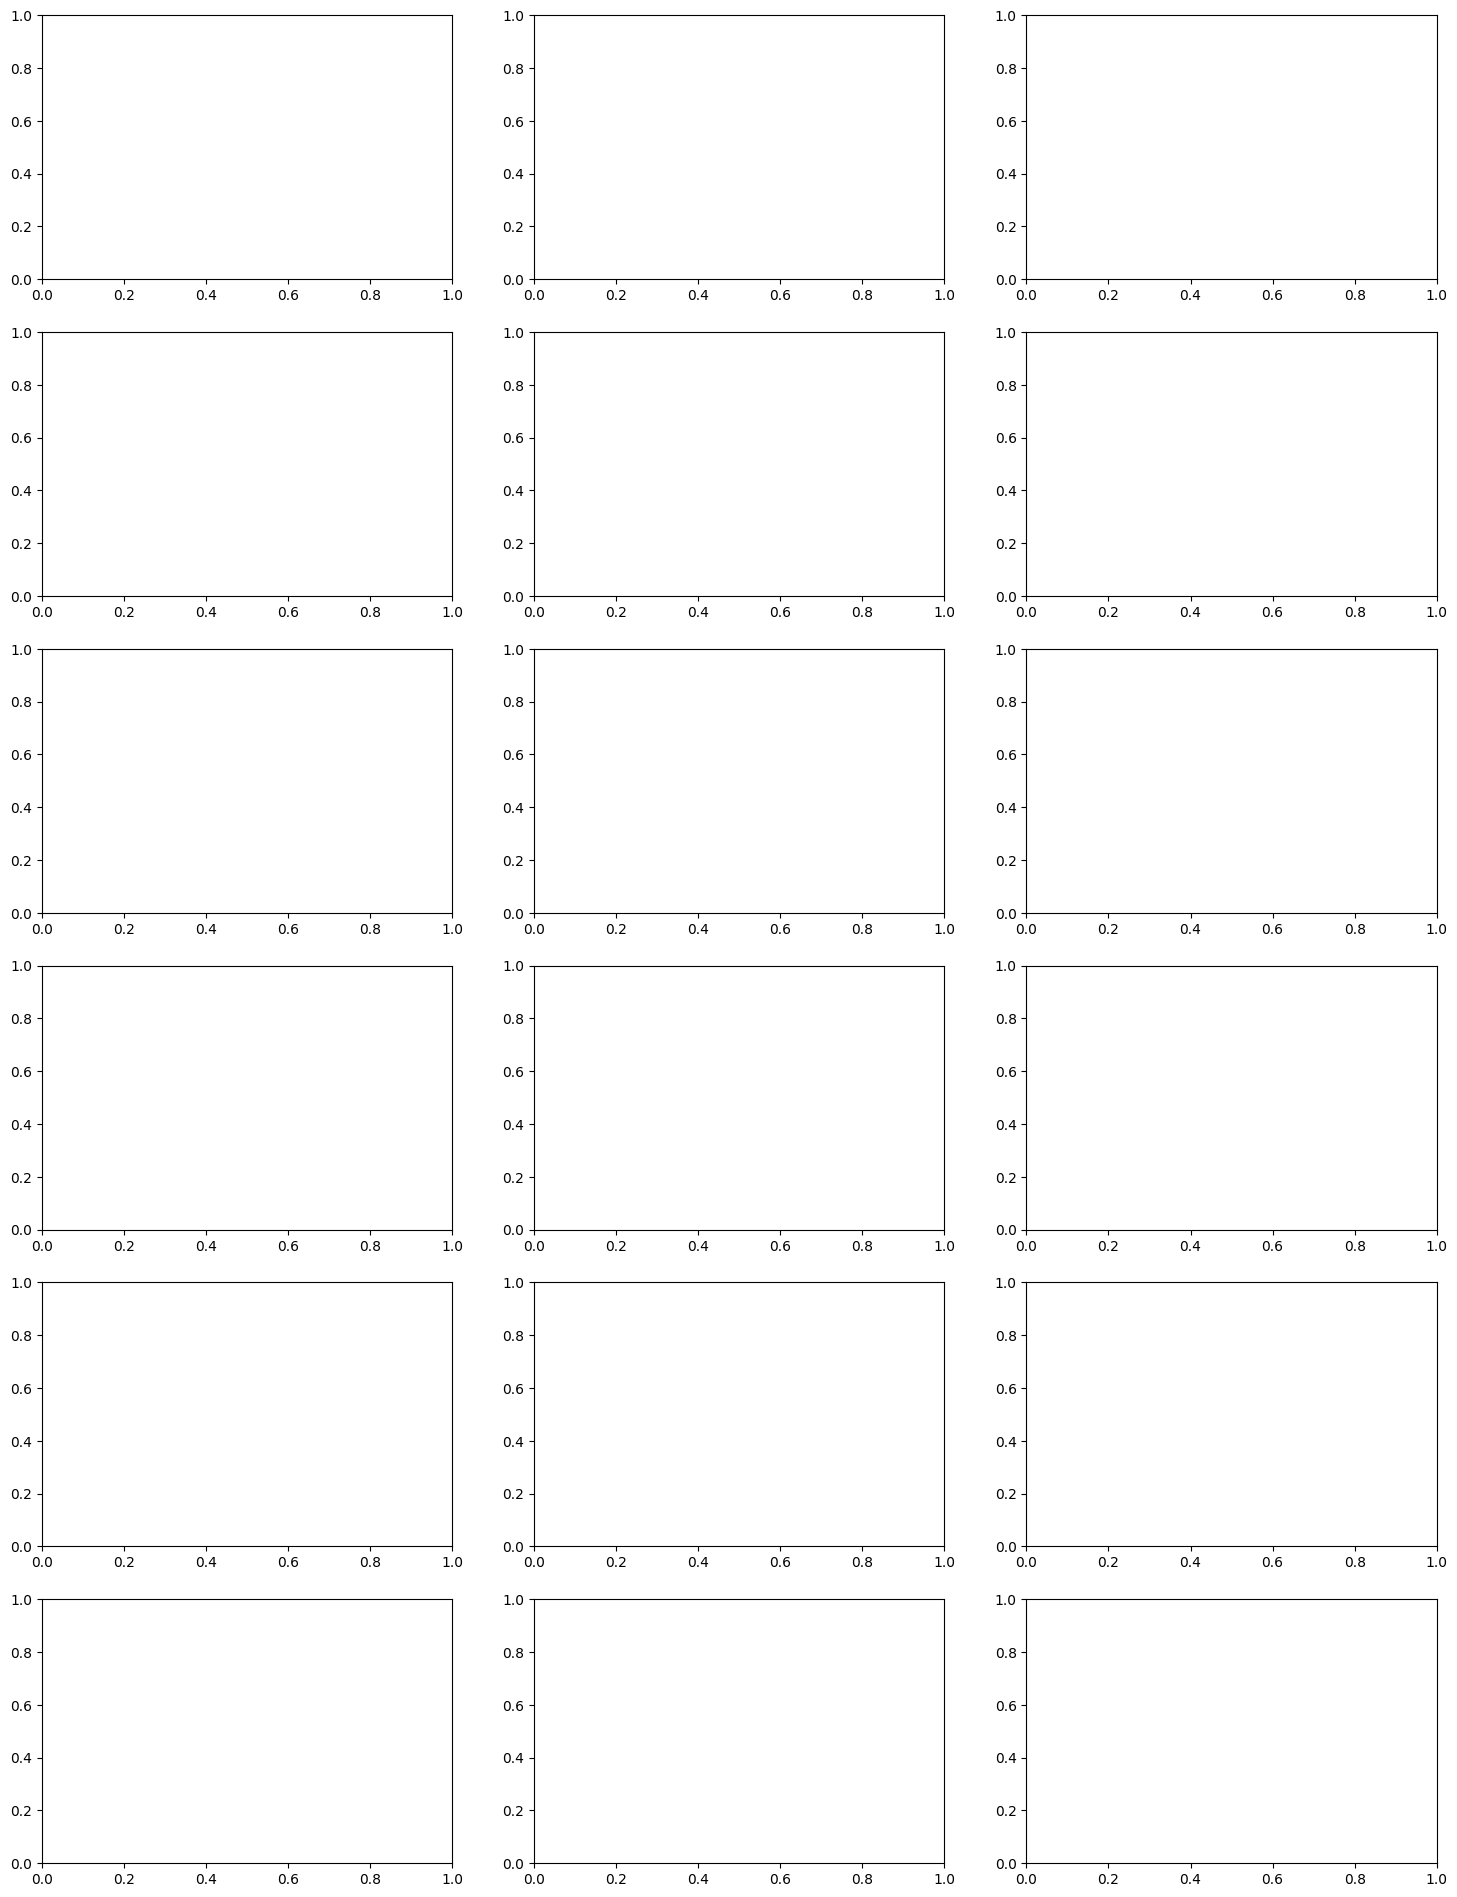

In [20]:
### START YOUR CODE
num_epochs = 25
input_size = X_train.shape[-1] * X_train.shape[-2]

settings = [
    {
        'num_layers': 2,
        'hidden_size': 512
    },
    {
        'num_layers': 2,
        'hidden_size': 1024
    },
    {
        'num_layers': 2,
        'hidden_size': 2048
    },
    {
        'num_layers': 4,
        'hidden_size': 512
    },
    {
        'num_layers': 4,
        'hidden_size': 1024
    },
    {
        'num_layers': 4,
        'hidden_size': 2048
    }
]
criterion = nn.CrossEntropyLoss()

fig, axes = plt.subplots(len(settings), 3, figsize=(18, 4 * len(settings)))

for i, setting in enumerate(settings):
    hidden_size = setting['hidden_size']
    num_layers = setting['num_layers']
    print(f"Run {i+1} with hidden_size {hidden_size} and {num_layers} Layers.")

    # Create Model
    model = MLPClassifier(input_size, hidden_size, num_layers).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses, train_accs, val_accs, total_preds, total_targets = trainer(model, train_loader, test_loader, optimizer, criterion, num_epochs, verbose=False)

    axes[i, 0].plot(train_losses, label='Training loss')
    axes[i, 0].plot(val_losses, label='Val loss')
    axes[i, 0].set_title(f"Loss (HS: {hidden_size}, {num_layers} Layers)")
    axes[i, 0].legend()
    axes[i, 0].grid()

    axes[i, 1].plot(train_accs, label='Training acc')
    axes[i, 1].plot(val_accs, label='Val acc')
    axes[i, 1].set_title(f"Accuracy (HS: {hidden_size}, {num_layers} Layers)")
    axes[i, 1].legend()
    axes[i, 1].grid()

    cm = confusion_matrix(torch.cat(total_targets), torch.cat(total_preds))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i, 2], cmap="Blues")

plt.show()

In [ ]:
...

#### Findings

...